The Steam merchandising team wants to compare mean listed prices across eight major game genres: Action, Adventure, Casual, Indie, RPG, Strategy, Simulation, and Sports.

The relevant fields are:

* `genres` — the genres assigned to each game
* `price` — the listed Steam price

The dataset is filtered to retain games whose `genres` value matches one of the requested genres: Action, Adventure, Casual, Indie, RPG, Strategy, Simulation, or Sports.

Each retained `genres` value is treated as the game's genre category. Records containing other genre values are excluded so that the comparison focuses only on the requested categories.

The `price` field is converted to numeric values before aggregation. Records with missing or invalid prices are excluded from the corresponding genre mean rather than interpreted as zero-priced games.

For each requested genre, the analysis calculates:

* the number of selected games,
* the number of valid price observations,
* the mean listed price,
* and the median listed price as supplementary context.

The genres are then ranked by mean listed price. The highest-ranked genre is identified as the genre with the highest average listed price, and its mean price is reported as the final result.

The resulting genre-level samples provide a direct comparison of listed prices across the eight requested categories.

Games selected: 3,843

Selected games by genre:

Selected records with missing or invalid prices: 0

Mean price comparison by genre:
           genre  game_count  valid_price_count mean_price median_price
rank                                                                   
1         Sports          63                 63     $13.80        $8.99
2            RPG         270                270     $11.97        $8.15
3     Simulation         328                328     $10.87        $6.99
4       Strategy         485                485     $10.41        $6.99
5         Action         843                843      $9.98        $6.99
6      Adventure         535                535      $8.73        $6.99
7         Casual         560                560      $4.68        $3.99
8          Indie         759                759      $3.97        $2.89

Final result:
Genre with the highest average price: Sports
Highest average price: $13.80


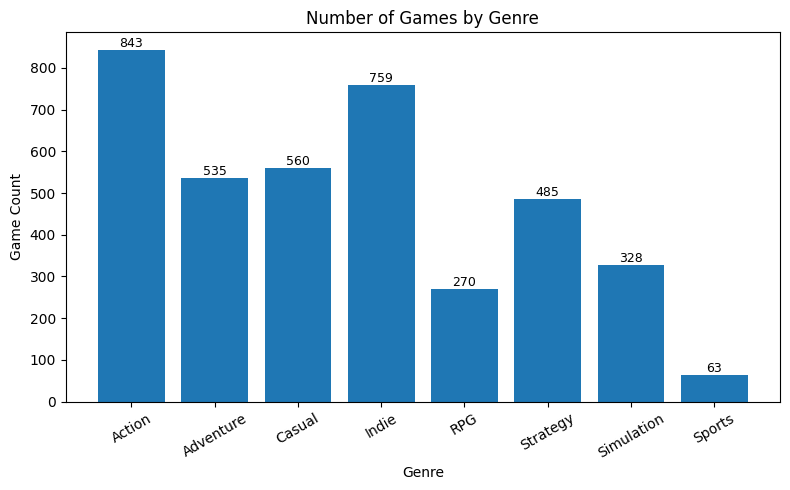

In [8]:
from pathlib import Path

import pandas as pd


STEAM_PATH = "../../data/steam/steam.csv"

TARGET_GENRES = [
    "Action",
    "Adventure",
    "Casual",
    "Indie",
    "RPG",
    "Strategy",
    "Simulation",
    "Sports",
]


def load_steam(path: str) -> pd.DataFrame:
    """Load the Steam dataset and validate the required columns."""
    file_path = Path(path)

    if not file_path.exists():
        raise FileNotFoundError(
            f"File not found: {file_path}"
        )

    steam = pd.read_csv(file_path)

    required_columns = {
        "genres",
        "price",
    }

    missing_columns = required_columns - set(steam.columns)

    if missing_columns:
        raise ValueError(
            f"Missing required columns: "
            f"{sorted(missing_columns)}"
        )

    steam = steam.copy()

    steam["price"] = pd.to_numeric(
        steam["price"],
        errors="coerce",
    )

    return steam


steam = load_steam(STEAM_PATH)


# Retain records whose genre value exactly matches
# one of the requested genre categories.
genre_long = steam[
    steam["genres"].isin(TARGET_GENRES)
].copy()


print(
    "Games selected:",
    f"{len(genre_long):,}",
)


print("\nSelected games by genre:")


# Count records with missing or invalid prices.
missing_price_count = (
    genre_long["price"]
    .isna()
    .sum()
)

print(
    "\nSelected records with missing or invalid prices:",
    f"{missing_price_count:,}",
)


# Calculate genre-level price statistics.
genre_price_summary = (
    genre_long
    .groupby("genres", observed=True)
    .agg(
        game_count=("genres", "size"),
        valid_price_count=("price", "count"),
        mean_price=("price", "mean"),
        median_price=("price", "median"),
    )
    .reindex(TARGET_GENRES)
    .rename_axis("genre")
    .reset_index()
)


# Rank genres by mean listed price.
genre_price_ranking = (
    genre_price_summary
    .sort_values(
        "mean_price",
        ascending=False,
        na_position="last",
    )
    .reset_index(drop=True)
)

genre_price_ranking.index = (
    genre_price_ranking.index + 1
)

genre_price_ranking.index.name = "rank"


# Create a formatted copy for display.
display_summary = genre_price_ranking.copy()

display_summary["mean_price"] = (
    display_summary["mean_price"]
    .map(
        lambda value: (
            f"${value:.2f}"
            if pd.notna(value)
            else "N/A"
        )
    )
)

display_summary["median_price"] = (
    display_summary["median_price"]
    .map(
        lambda value: (
            f"${value:.2f}"
            if pd.notna(value)
            else "N/A"
        )
    )
)


print("\nMean price comparison by genre:")
print(display_summary.to_string())


# Identify the genre with the highest mean price.
valid_results = genre_price_ranking.dropna(
    subset=["mean_price"]
)

if valid_results.empty:
    raise ValueError(
        "No valid price observations were available "
        "for the requested genres."
    )

highest_mean_row = valid_results.iloc[0]

highest_mean_genre = highest_mean_row["genre"]
highest_mean_price = highest_mean_row["mean_price"]


print("\nFinal result:")

print(
    "Genre with the highest average price:",
    highest_mean_genre,
)

print(
    "Highest average price:",
    f"${highest_mean_price:.2f}",
)

import matplotlib.pyplot as plt

plot_data = (
    genre_price_summary
    .copy()
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    plot_data["genre"],
    plot_data["game_count"],
)

plt.title("Number of Games by Genre")
plt.xlabel("Genre")
plt.ylabel("Game Count")

plt.xticks(rotation=30)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()